In [ ]:
from pathlib import Path
import json
import re

import evaluate
import pandas as pd

path = Path("review_outputs/stage2_model_answers.jsonl")
metric = evaluate.load("squad")


def get_prediction(row: dict) -> str:
    answer = row.get("answer")
    if answer not in (None, "", "None"):
        return str(answer)

    model_raw = row.get("model_raw", "")
    if not model_raw:
        return ""

    match = re.search(r"\{.*?\}", model_raw, re.DOTALL)
    if match is None:
        return ""

    try:
        payload = json.loads(match.group(0))
    except json.JSONDecodeError:
        return ""

    prediction = payload.get("answer", "")
    if prediction in (None, "None"):
        return ""
    return str(prediction)


def build_prediction_row(row: dict) -> dict:
    reference_answer = str(row.get("reference_answer", ""))
    prediction = get_prediction(row)
    if isinstance(row.get("reference_answer", None), list) and len(reference_answer) == 1:
        print("Пу пу")

    score = metric.compute(
        predictions=[
            {
                "id": str(row.get("qid", "")),
                "prediction_text": prediction,
            }
        ],
        references=[
            {
                "id": str(row.get("qid", "")),
                "answers": {
                    "text": [reference_answer],
                    "answer_start": [0],
                },
            }
        ],
    )

    return {
        "qid": row.get("qid"),
        "reference_answer": reference_answer,
        "prediction": prediction,
        "em": score["exact_match"],
        "f1": score["f1"],
    }


rows = []
with path.open(encoding="utf-8") as f:
    for line in f:
        row = json.loads(line)
        rows.append(build_prediction_row(row))

result_df = pd.DataFrame(rows)
result_df["has_prediction"] = result_df["prediction"].str.len().gt(0)

summary = {
    "samples": len(result_df),
    "missing_predictions": int((~result_df["has_prediction"]).sum()),
    "exact_match": float(result_df["em"].mean()) if len(result_df) else 0.0,
    "f1": float(result_df["f1"].mean()) if len(result_df) else 0.0,
}

result_df.to_csv("review_outputs/stage2_generation_metrics.csv", index=False, encoding="utf-8")
summary

{'samples': 1000,
 'missing_predictions': 21,
 'exact_match': 67.1,
 'f1': 68.93056895973439}

In [13]:
import numpy as np


def bootstrap_ci(values, n_resamples: int = 2000, confidence_level: float = 0.95, seed: int = 42):
    values = np.asarray(values, dtype=float)
    if len(values) == 0:
        return {"mean": 0.0, "lower": 0.0, "upper": 0.0}

    rng = np.random.default_rng(seed)
    resampled_means = np.empty(n_resamples, dtype=float)
    for i in range(n_resamples):
        sample = rng.choice(values, size=len(values), replace=True)
        resampled_means[i] = sample.mean()

    alpha = (1.0 - confidence_level) / 2.0
    lower = float(np.quantile(resampled_means, alpha))
    upper = float(np.quantile(resampled_means, 1.0 - alpha))
    return {"mean": float(values.mean()), "lower": lower, "upper": upper}


ci_summary = {
    "samples": len(result_df),
    "missing_predictions": int((~result_df["has_prediction"]).sum()),
    "exact_match": bootstrap_ci(result_df["em"].to_numpy()),
    "f1": bootstrap_ci(result_df["f1"].to_numpy()),
}

ci_summary

{'samples': 1000,
 'missing_predictions': 21,
 'exact_match': {'mean': 67.1, 'lower': 64.2, 'upper': 69.9},
 'f1': {'mean': 68.93056895973439,
  'lower': 66.13812810459349,
  'upper': 71.65264055364543}}

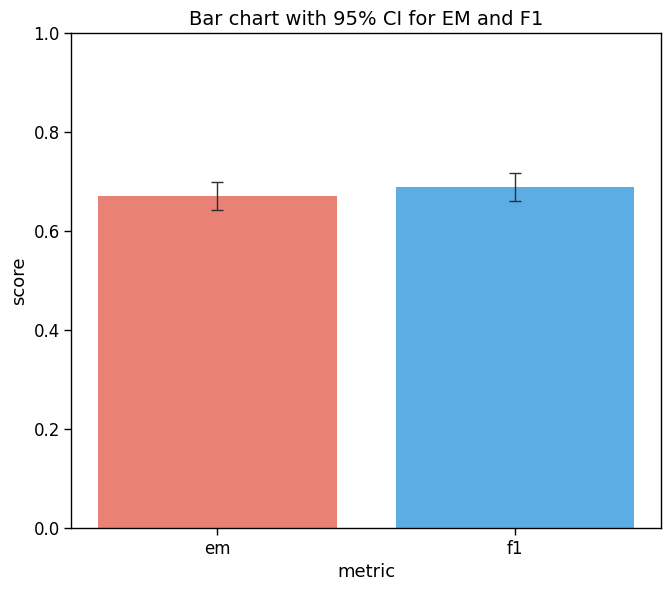

,metric,mean,lower,upper
0,em,0.671000,0.642000,0.699000
1,f1,0.689306,0.661381,0.716526


In [1]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use("seaborn-v0_8-pastel")
sns.set_context("paper", font_scale=1.0)
plt.rcParams.update(
    {
        "axes.titlesize": 14,
        "axes.labelsize": 13,
        "xtick.labelsize": 12,
        "ytick.labelsize": 12,
        "legend.fontsize": 11,
        "legend.title_fontsize": 12,
    }
)


def bootstrap_ci(values, n_resamples: int = 2000, confidence_level: float = 0.95, seed: int = 42):
    values = np.asarray(values, dtype=float)
    if len(values) == 0:
        return {"mean": 0.0, "lower": 0.0, "upper": 0.0}

    rng = np.random.default_rng(seed)
    resampled_means = np.empty(n_resamples, dtype=float)
    for i in range(n_resamples):
        sample = rng.choice(values, size=len(values), replace=True)
        resampled_means[i] = sample.mean()

    alpha = (1.0 - confidence_level) / 2.0
    return {
        "mean": float(values.mean()),
        "lower": float(np.quantile(resampled_means, alpha)),
        "upper": float(np.quantile(resampled_means, 1.0 - alpha)),
    }


plot_source_df = pd.read_csv("review_outputs/stage2_generation_metrics.csv")

metric_columns = ["em", "f1"]
plot_source_df[metric_columns] = plot_source_df[metric_columns] / 100.0
plot_source_df[metric_columns] = plot_source_df[metric_columns].clip(0.0, 1.0)

summary_rows = []
for metric_name in metric_columns:
    stats = bootstrap_ci(plot_source_df[metric_name].dropna().to_numpy())
    summary_rows.append(
        {
            "metric": metric_name,
            "mean": stats["mean"],
            "lower": stats["lower"],
            "upper": stats["upper"],
        }
    )

summary_df = pd.DataFrame(summary_rows)

palette = {"em": "#fe7161", "f1": "#45b2fa"}
fig, ax = plt.subplots(figsize=(6.8, 6))
sns.barplot(
    data=summary_df,
    x="metric",
    y="mean",
    order=metric_columns,
    hue="metric",
    palette=palette,
    dodge=False,
    ax=ax,
    errorbar=None,
    legend=False,
    linewidth=0,
    edgecolor="none",
)

x_positions = np.arange(len(summary_df))
ax.errorbar(
    x_positions,
    summary_df["mean"],
    yerr=[summary_df["mean"] - summary_df["lower"], summary_df["upper"] - summary_df["mean"]],
    fmt="none",
    ecolor="#2F2F2F",
    capsize=4,
    linewidth=1.0,
    zorder=10,
)

ax.set_ylim(0, 1)
ax.set_xlabel("metric")
ax.set_ylabel("score")
ax.set_title("Bar chart with 95% CI for EM and F1")
ax.tick_params(axis="both", labelsize=12)
plt.tight_layout()
plt.show()

summary_df